# 🤖 Notebook 13: Motor de Predição Operacional (Teste vs Futuro)

Este notebook gera as recomendações de produção para a cozinha. 

**⚠️ IMPORTANTE:**
Este notebook consome o arquivo anonimizado gerado pelo **Notebook 12**.

# Metodologia Design Science Research (DSR) - NB13

## 1. Problema e Motivação
A lacuna entre o modelo experimental e a aplicação prática diária na cozinha, onde a predição precisa ser traduzida em ordens de produção.

## 2. Objetivos da Solução
Criar um motor de inferência que combine a estabilidade das reservas com a inteligência exploratória dos modelos de Machine Learning (Ensemble XGBoost, LightGBM, CatBoost).

## 3. Design e Desenvolvimento
Desenvolvimento de um sistema de "Shadowing" que permite auditar a performance do modelo em dados históricos recentes antes da aplicação em predições futuras.

## 4. Demonstração
O motor demonstra como a predição híbrida (70% IA / 30% Reserva) oferece um equilíbrio robusto, mitigando os riscos de subestimar a demanda em dias de alta volatilidade.

## 5. Avaliação
A avaliação é feita através da "Auditoria de Precisão", comparando o realizado vs predito em janelas operacionais reais, validando a eficácia do artefato em ambiente simulado de produção.


In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "../data/"
INPUT_PATH = os.path.join(BASE_PATH, "predicao/")
print("✅ Motor 13 inicializado com Suporte a Ensemble IA real.")

✅ Motor 13 inicializado com Suporte a Ensemble IA real.


In [2]:
try:
    xlsx_files = glob.glob(os.path.join(INPUT_PATH, "*.xlsx"))
    csv_output = os.path.join(INPUT_PATH, "reservas_consolidadas_predicao.csv")

    if xlsx_files:
        latest_xlsx = max(xlsx_files, key=os.path.getmtime)
        if not os.path.exists(csv_output) or os.path.getmtime(latest_xlsx) > os.path.getmtime(csv_output):
            print("🛑 ERRO: Execute o 'Notebook 12' para processar o Excel novo.")
            raise InterruptedError("Anonimização pendente.")

    df_input_raw = pd.read_csv(csv_output)
    df_input_raw["data"] = pd.to_datetime(df_input_raw["data"])
    
    # AGREGAR POR DATA para a predição (total_reservas)
    df_input = df_input_raw.groupby("data").size().reset_index(name="total_reservas")
    
    print(f"📂 Dados carregados: {len(df_input)} dias de reservas identificados.")

    # Carregar base de treino para o Ensemble
    df_train_full = pd.read_csv(os.path.join(BASE_PATH, "base_features_selecionadas.csv"))
    df_train_full["data"] = pd.to_datetime(df_train_full["data"])
    
    # Carregar Embeddings BERT
    df_bert = pd.read_csv(os.path.join(BASE_PATH, "embeddings_bert_cardapio.csv"))
    df_bert["data"] = pd.to_datetime(df_bert["data"])
    
    # Merge nos dados de treino
    df_train_full = pd.merge(df_train_full, df_bert, on="data", how="inner")
    
    shadow_mask = df_input["data"].isin(df_train_full["data"])
    IS_SHADOWING = shadow_mask.any()

    df_cardapio = pd.read_csv(os.path.join(BASE_PATH, "cardapio_consolidado.csv"))
    df_cardapio["data"] = pd.to_datetime(df_cardapio["data"])
    
    missing = df_input[~df_input["data"].isin(df_cardapio["data"])]
    if not missing.empty:
        print("🛑 ALERTA: Faltam pratos no cardápio!")
        for d in missing["data"]: print(f"- {d.strftime('%d/%m/%Y')}")
        HAS_ERROR = True
    else:
        HAS_ERROR = False

except Exception as e:
    print(f"❌ Erro: {e}")
    HAS_ERROR = True

📂 Dados carregados: 1 dias de reservas identificados.


In [3]:
if "HAS_ERROR" in locals() and not HAS_ERROR:
    print("🧠 Treinando Comitê Preditivo (XGB + LGBM + CAT)... Ensembles Híbridos...")
    TARGET = "total_servido" if "total_servido" in df_train_full.columns else "servida"
    
    features = [c for c in df_train_full.columns if c not in [TARGET, "data", "base_servida", "reserva", "total_reservas"]]
    
    m_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
    m_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
    m_cat = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=6, verbose=0, random_state=42)
    
    m_xgb.fit(df_train_full[features], df_train_full[TARGET])
    m_lgb.fit(df_train_full[features], df_train_full[TARGET])
    m_cat.fit(df_train_full[features], df_train_full[TARGET])
    
    df_infer = pd.merge(df_input, df_train_full[features + ["data"]], on="data", how="left")
    
    if df_infer[features].isnull().any().any():
        df_infer = df_infer.drop(columns=[c for c in df_bert.columns if c in df_infer.columns and c != "data"])
        df_infer = pd.merge(df_infer, df_bert, on="data", how="left")
        for f in features: 
            if f in df_infer.columns and df_infer[f].isnull().any():
                df_infer[f] = df_infer[f].fillna(df_train_full[f].median())

    preds_ml = (m_xgb.predict(df_infer[features]) + m_lgb.predict(df_infer[features]) + m_cat.predict(df_infer[features])) / 3
    
    df_infer["Predição IA"] = np.ceil((0.7 * preds_ml) + (0.3 * df_infer["total_reservas"]))
    
    # --- Monte Carlo Safety Margin ---
    print("🎲 Gerando Margem de Segurança Monte Carlo (Confiança 95%)...")
    residuals = df_train_full[TARGET] - m_cat.predict(df_train_full[features])
    mu, std = stats.norm.fit(residuals)
    
    def simulate_margin(point_pred, error_std, n_sims=5000):
        sims = np.random.normal(point_pred, error_std, n_sims)
        return np.percentile(np.maximum(sims, 0), 95)
    
    df_infer["Meta Cozinha (Segurança)"] = df_infer["Predição IA"].apply(lambda x: np.ceil(simulate_margin(x, std)))
    # ---------------------------------
    
    df_infer["Meta Cozinha"] = np.ceil(df_infer["Predição IA"] * 1.12)
    
    print("✅ Predição Ensemble Híbrida concluída.")

🧠 Treinando Comitê Preditivo (XGB + LGBM + CAT)... Ensembles Híbridos...
🎲 Gerando Margem de Segurança Monte Carlo (Confiança 95%)...
✅ Predição Ensemble Híbrida concluída.


📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de 22.0 refeições


,data,total_reservas,total_servido,Predição IA,Meta Cozinha (Segurança)
0,2025-08-22,191,111.0,133.0,170.0


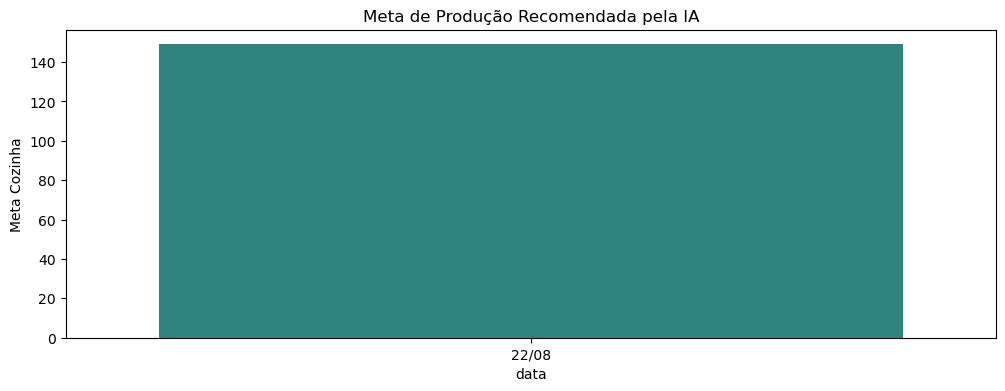

In [4]:
if "df_infer" in locals() and not HAS_ERROR:
    if IS_SHADOWING:
        target = "total_servido" if "total_servido" in df_train_full.columns else "servida"
        df_eval = pd.merge(df_infer, df_train_full[["data", target]], on="data")
        mae = mean_absolute_error(df_eval[target], df_eval["Predição IA"])
        print(f"📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de {mae:.1f} refeições")
        display(df_eval[["data", "total_reservas", target, "Predição IA", "Meta Cozinha (Segurança)"]])
    else:
        print("🔮 RECOMENDAÇÃO FUTURA (Baseada em Comitê de IA Profissional):")
        display(df_infer[["data", "total_reservas", "Predição IA", "Meta Cozinha", "Meta Cozinha (Segurança)"]])
        
    plt.figure(figsize=(12, 4))
    sns.barplot(x=df_infer["data"].dt.strftime("%d/%m"), y=df_infer["Meta Cozinha"], palette="viridis")
    plt.title("Meta de Produção Recomendada pela IA"); plt.show()